# Session 5

In today's session we will learn about how to extract spectra from the MIRI IFU spectral cube, JWST. We will also identify emission lines.

This session will become the base of one of your projects. So take it seriously!!

## Spectral Cube

Unlike image that has 2 spatial axis, this has one spectral axis too. It can be in wavelength,frequency or velocity.

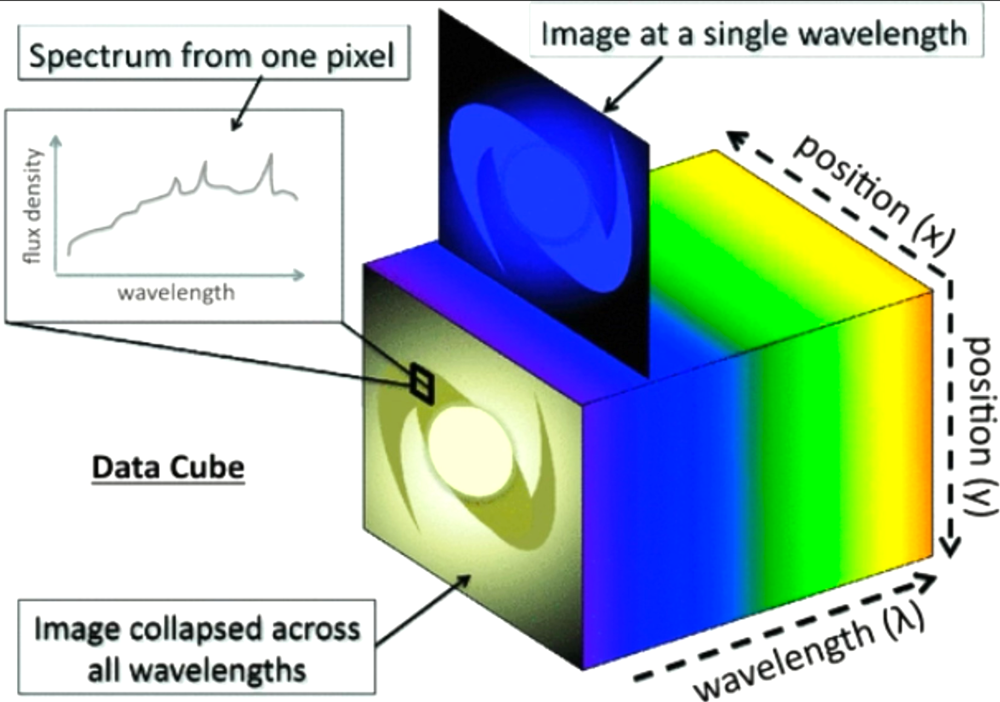

JWST has the following instruments:

1. NIRCam
2. NIRSpec
3. MIRI     --> We will use this today!

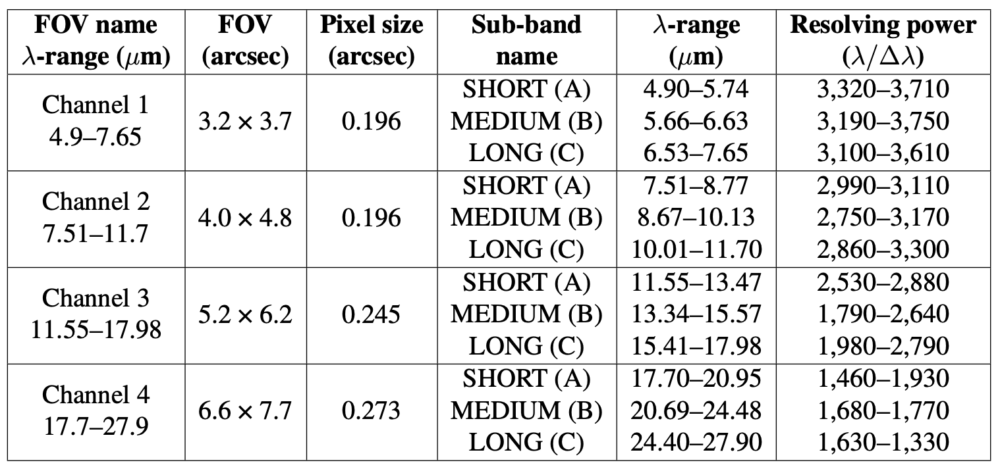

You can read more here: https://jwst-docs.stsci.edu/jwst-mid-infrared-instrument#gsc.tab=0

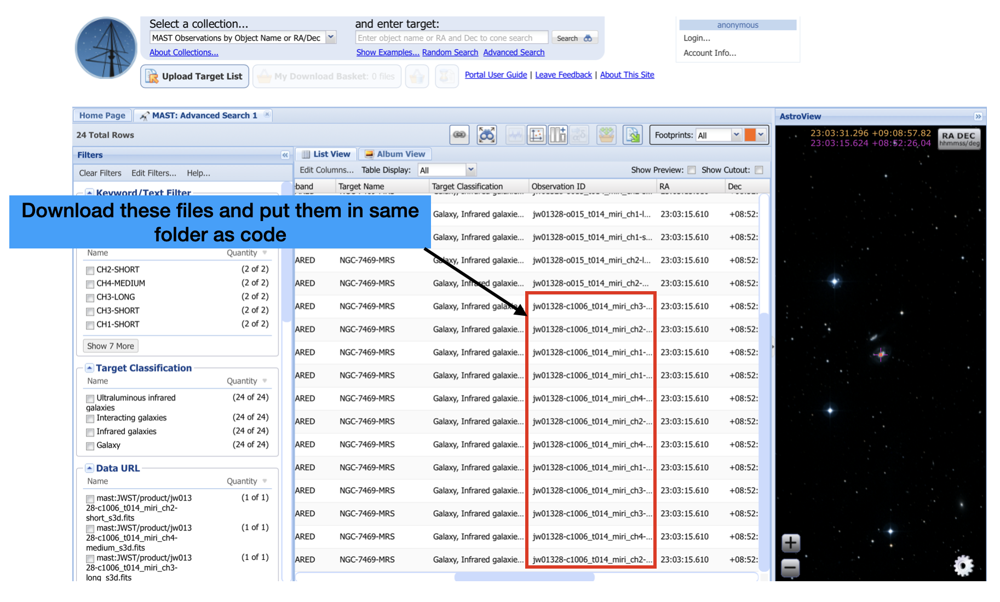

Make sure to download the -c1006 files because that means it is calibrated. These are level 3 files (_x3d.fits) i.e. science ready. Refer to the session 3 (exploring data archive session) to understand how to use MAST portal.

# regions

regions is an in-development coordinated package of Astropy for region handling.

The Regions package provides classes to represent:

    Regions defined using pixel coordinates (e.g., CirclePixelRegion)
    Regions defined using celestial coordinates, but still in an Euclidean geometry (e.g., CircleSkyRegion)
    To transform between sky and pixel regions, a world coordinate system object (e.g., astropy.wcs.WCS) is needed.

Regions also provides a unified interface for reading, writing, parsing, and serializing regions data in different formats, including the DS9 Region Format, CRTF (CASA Region Text Format), and FITS Region Binary Table format.

You can read more about it in here:

https://astropy-regions.readthedocs.io/en/stable/shapes.html

In [13]:
#Region-wise line plotting

# Import necessary libraries
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from regions import Regions

warnings.filterwarnings("ignore", category=UserWarning, append=True)

In [14]:
# Define the redshift for NGC 7469
# NGC 7469 is a Seyfert galaxy with a redshift of approximately 0.016268
# This value is used to convert observed wavelengths to rest-frame wavelengths
# The redshift value can be obtained from various astronomical databases like NED (NASA/IPAC Extragalactic Database)

z = 0.016268

reg_path = "region_file.reg" # From DS9 lecture, this is the region file containing the regions of interest
# Read the regions from the DS9 region file
# Make sure to have the regions file in the same directory as this script
regions = Regions.read(reg_path, format='ds9')
region_labels = ["Center Region", "Ring Region"]  # Label for each region

file_paths = []

# Only channel 2 for the session
#for part in ['short','medium','long']:
        # I have kept them in a subfolder MAST_NGC_7469 for clarity
        # You can change the path as per your directory structure
        # The file names are based on the JWST data release naming convention
       # file_paths.append(f'./MAST_NGC_7469/jw01328-c1006_t014_miri_ch{2}-{part}_s3d.fits')


for ch_num in range(1,5):
     for part in ['short','medium','long']:
         file_paths.append(f'./MAST_NGC_7469/jw01328-c1006_t014_miri_ch{ch_num}-{part}_s3d.fits')

print(file_paths)

['./MAST_NGC_7469/jw01328-c1006_t014_miri_ch1-short_s3d.fits', './MAST_NGC_7469/jw01328-c1006_t014_miri_ch1-medium_s3d.fits', './MAST_NGC_7469/jw01328-c1006_t014_miri_ch1-long_s3d.fits', './MAST_NGC_7469/jw01328-c1006_t014_miri_ch2-short_s3d.fits', './MAST_NGC_7469/jw01328-c1006_t014_miri_ch2-medium_s3d.fits', './MAST_NGC_7469/jw01328-c1006_t014_miri_ch2-long_s3d.fits', './MAST_NGC_7469/jw01328-c1006_t014_miri_ch3-short_s3d.fits', './MAST_NGC_7469/jw01328-c1006_t014_miri_ch3-medium_s3d.fits', './MAST_NGC_7469/jw01328-c1006_t014_miri_ch3-long_s3d.fits', './MAST_NGC_7469/jw01328-c1006_t014_miri_ch4-short_s3d.fits', './MAST_NGC_7469/jw01328-c1006_t014_miri_ch4-medium_s3d.fits', './MAST_NGC_7469/jw01328-c1006_t014_miri_ch4-long_s3d.fits']


Now we have defined the redshift from NED, made a region file from DS9 and made a list of all the files to iterate over. 

We can proceed further and extract the spectra from each of the file and plot the final spectrum from it.

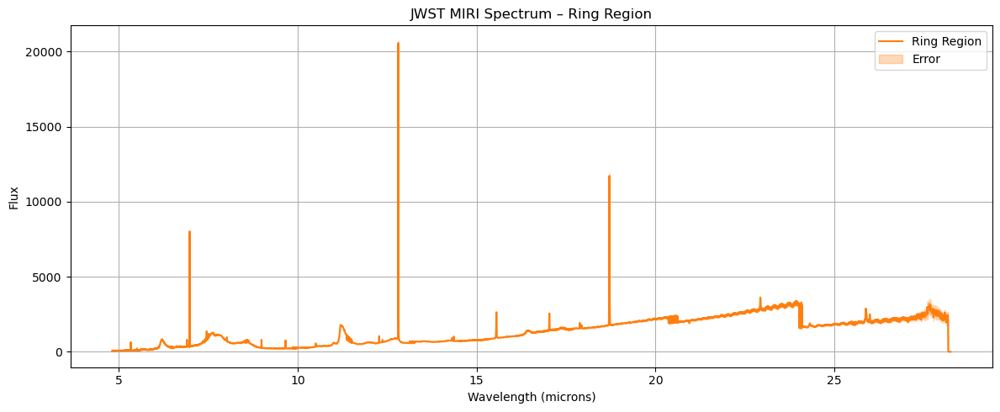

In [16]:

from astropy.wcs import FITSFixedWarning

# Suppress FITSFixedWarning
warnings.simplefilter('ignore', category=FITSFixedWarning)

# Loop through each region
for idx, region in enumerate(regions):
    label = region_labels[idx] if idx < len(region_labels) else f"Region {idx+1}"

    wavelength_all = []
    spectrum_all = []
    spectrum_all_err = []

    for file_path in file_paths:
        try:
            hdul = fits.open(file_path)
            data = hdul[1].data
            data[data < 0] = np.nan
            data_err = hdul[2].data
            header = hdul[1].header
            wcs = WCS(header)

            mask = region.to_pixel(wcs.celestial).to_mask()

            spectrum = []
            spectrum_err = []

            for i in range(data.shape[0]):
                masked_data = mask.multiply(data[i, :, :])
                masked_err = mask.multiply(data_err[i, :, :])

                avg = np.nanmean(masked_data)
                err = np.sqrt(np.nanmean(masked_err**2))

                spectrum.append(avg if not np.isnan(avg) else 0)
                spectrum_err.append(err if not np.isnan(err) else 0)

            crval = header['CRVAL3']
            cdelt = header['CDELT3']
            crpix = header['CRPIX3']
            wl = (np.arange(data.shape[0]) - (crpix - 1)) * cdelt + crval
            wl = wl / (1 + z)

            wavelength_all.extend(wl)
            spectrum_all.extend(spectrum)
            spectrum_all_err.extend(spectrum_err)

            hdul.close()
        except Exception as e:
            print(f"Error with {file_path}: {e}")

    # Sort
    wavelength_all = np.array(wavelength_all)
    spectrum_all = np.array(spectrum_all)
    spectrum_all_err = np.array(spectrum_all_err)

    sorted_idx = np.argsort(wavelength_all)
    wavelength_all = wavelength_all[sorted_idx]
    spectrum_all = spectrum_all[sorted_idx]
    spectrum_all_err = spectrum_all_err[sorted_idx]

#saving the individual spectral plots as a csv file 

# Create DataFrame
df = pd.DataFrame({
    'Wavelength (microns)': wavelength_all,
    'Flux': spectrum_all,
    'Flux Error': spectrum_all_err
})

# Generate filename based on region name
fname = label.replace(" ", "_").lower()  # e.g., 'center_region'

# Save as CSV
df.to_csv(f"{fname}_spectrum.csv", index=False)
 # Plot
plt.figure(figsize=(12, 5))
plt.plot(wavelength_all, spectrum_all, label=label, color='C'+str(idx))
plt.fill_between(wavelength_all,
                     spectrum_all - spectrum_all_err,
                     spectrum_all + spectrum_all_err,
                     color='C'+str(idx), alpha=0.3, label='Error')
plt.xlabel('Wavelength (microns)')
plt.ylabel('Flux')
plt.title(f'JWST MIRI Spectrum – {label}')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f"{label.replace(' ', '_').lower()}_spectrum.png")  # Optional: save as PNG
plt.show()

    # Optional: export to CSV
import pandas as pd
df = pd.DataFrame({
    'Wavelength (microns)': wavelength_all,
    'Flux': spectrum_all,
    'Flux Error': spectrum_all_err
})
df.to_csv(f"{label.replace(' ', '_').lower()}_spectrum.csv", index=False)


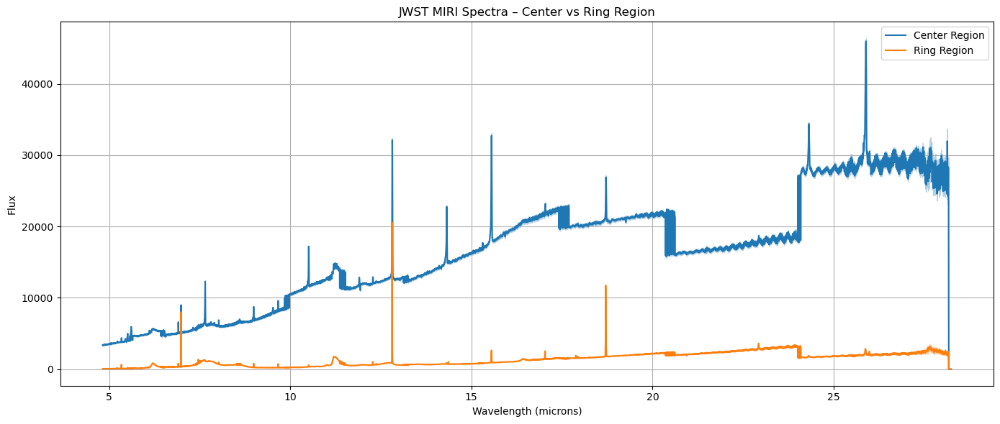

In [17]:
# Load extracted spectra from CSVs
center_df = pd.read_csv("center_region_spectrum.csv")
ring_df = pd.read_csv("ring_region_spectrum.csv")

# Extract data
wl_center = center_df['Wavelength (microns)']
flux_center = center_df['Flux']
err_center = center_df['Flux Error']

wl_ring = ring_df['Wavelength (microns)']
flux_ring = ring_df['Flux']
err_ring = ring_df['Flux Error']

# Plot
plt.figure(figsize=(14, 6))

plt.plot(wl_center, flux_center, label='Center Region', color='C0')
plt.fill_between(wl_center, flux_center - err_center, flux_center + err_center, color='C0', alpha=0.3)

plt.plot(wl_ring, flux_ring, label='Ring Region', color='C1')
plt.fill_between(wl_ring, flux_ring - err_ring, flux_ring + err_ring, color='C1', alpha=0.3)

plt.xlabel("Wavelength (microns)")
plt.ylabel("Flux")
plt.title("JWST MIRI Spectra – Center vs Ring Region")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("combined_regions_spectrum.png")
plt.show()


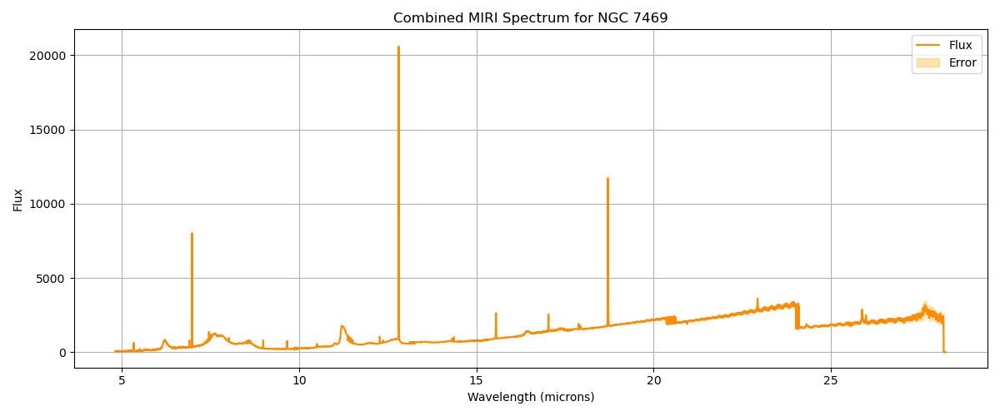

In [18]:
%matplotlib widget
plt.figure(figsize=(12, 5))
plt.plot(wavelength_all, spectrum_all, label='Flux', color='darkorange')
plt.fill_between(wavelength_all, 
                 spectrum_all - spectrum_all_err, 
                 spectrum_all + spectrum_all_err, 
                 color='orange', alpha=0.3, label='Error')
plt.xlabel('Wavelength (microns)')
plt.ylabel('Flux')
plt.title('Combined MIRI Spectrum for NGC 7469')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

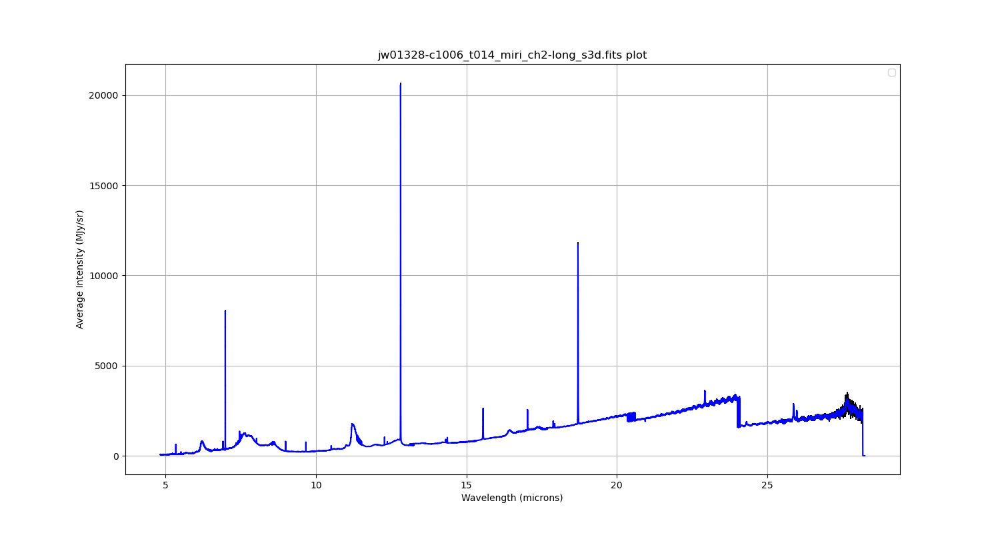

In [19]:
#plot using ./MAST_NGC_7469/jw01328-c1006_t014_miri_ch2-long_s3d.fits data
plt.figure(figsize=(15, 8))
plt.errorbar(wavelength_all, spectrum_all, yerr=spectrum_all_err, color='blue', ecolor='black')
plt.xlabel('Wavelength (microns)')
plt.ylabel('Average Intensity (MJy/sr)')
plt.title("jw01328-c1006_t014_miri_ch2-long_s3d.fits plot")

# Change the x-axis limits to focus on the desired region
# w_start, w_end = 8.95, 9.05
# plt.xlim(w_start, w_end)

# Auto-scale y-axis to the visible range
# plt.ylim(0, 1.1*np.nanmax(spectrum_all[(wavelength_all >= w_start) & (wavelength_all <= w_end)]))
plt.grid(True)
plt.legend()

## plotting spectra for all 12 files 

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from regions import Regions
import os

# Set up
z = 0.016268
reg_path = "region_file.reg"
regions = Regions.read(reg_path, format='ds9')
region_labels = ["Center Region", "Ring Region"]

# Define MIRI file paths and labels
file_paths = []
file_labels = []
for ch_num in range(1, 5):
    for part in ['short', 'medium', 'long']:
        path = f'./MAST_NGC_7469/jw01328-c1006_t014_miri_ch{ch_num}-{part}_s3d.fits'
        file_paths.append(path)
        file_labels.append(f"ch{ch_num}-{part}")

# Make output folder
os.makedirs("region_channel_plots", exist_ok=True)

# Loop through each region
for region_idx, region in enumerate(regions):
    region_name = region_labels[region_idx]
    safe_name = region_name.replace(" ", "_").lower()

    # Loop through each FITS file
    for file_path, file_label in zip(file_paths, file_labels):
        try:
            hdul = fits.open(file_path)
            data = hdul[1].data
            data[data < 0] = np.nan
            data_err = hdul[2].data
            header = hdul[1].header
            wcs = WCS(header)

            mask = region.to_pixel(wcs.celestial).to_mask()

            spectrum = []
            spectrum_err = []

            for i in range(data.shape[0]):
                masked_data = mask.multiply(data[i, :, :])
                masked_err = mask.multiply(data_err[i, :, :])

                avg = np.nanmean(masked_data)
                err = np.sqrt(np.nanmean(masked_err**2))

                spectrum.append(avg if not np.isnan(avg) else 0)
                spectrum_err.append(err if not np.isnan(err) else 0)

            crval = header['CRVAL3']
            cdelt = header['CDELT3']
            crpix = header['CRPIX3']
            wl = (np.arange(data.shape[0]) - (crpix - 1)) * cdelt + crval
            wl = wl / (1 + z)

            # Sort
            wl = np.array(wl)
            spectrum = np.array(spectrum)
            spectrum_err = np.array(spectrum_err)
            sorted_idx = np.argsort(wl)
            wl = wl[sorted_idx]
            spectrum = spectrum[sorted_idx]
            spectrum_err = spectrum_err[sorted_idx]

            # Plot
            plt.figure(figsize=(10, 4))
            plt.plot(wl, spectrum, label='Spectrum', color='C0')
            plt.fill_between(wl, spectrum - spectrum_err, spectrum + spectrum_err, color='C0', alpha=0.3, label='Error')
            plt.xlabel("Wavelength (μm)")
            plt.ylabel("Flux")
            plt.title(f"{region_name} — {file_label}")
            plt.legend()
            plt.tight_layout()
            

            # Save plot
            fname = f"region_channel_plots/{safe_name}_{file_label}.png"
            plt.savefig(fname)
            plt.close()

        except Exception as e:
            print(f"Failed for {file_path} and {region_name}: {e}")


In [22]:
# %pip install plotly

The code below is to plot and interactively view the final spectra. It might be complex so you can treat it as a black box or explore on your own.

Your task here is to fill the spectral features by opening each file in cubeviz. I will give you an example walkthrough.

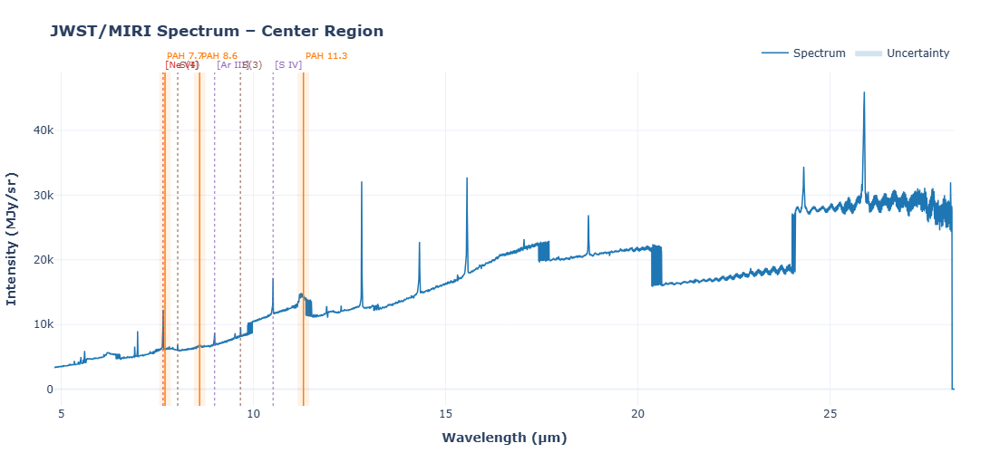

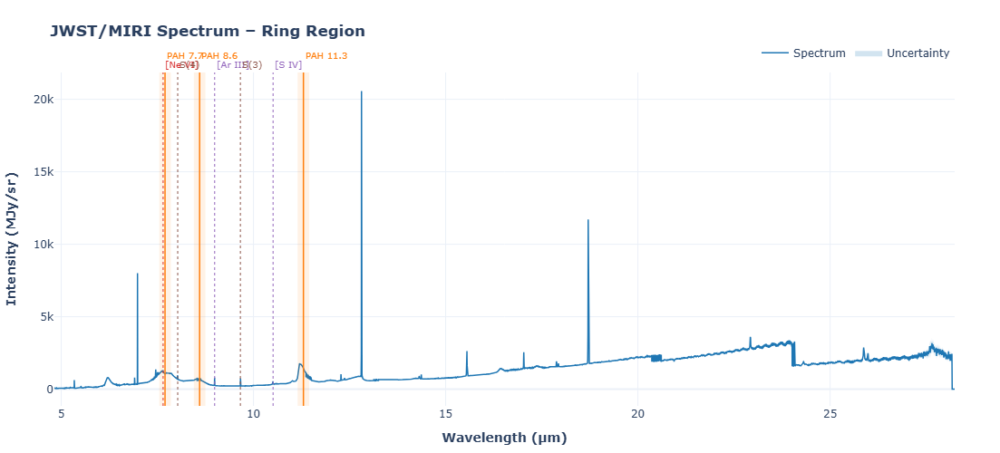

In [24]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Load spectra from CSV files
center_df = pd.read_csv("center_region_spectrum.csv")
ring_df = pd.read_csv("ring_region_spectrum.csv")

# Organize data for both regions
region_data = {
    "Center Region": center_df,
    "Ring Region": ring_df
}

# Define emission/molecular features
features = {
    'PAHs': {
         'PAH 7.7': 7.7, 'PAH 8.6': 8.6, 'PAH 11.3': 11.3,
    },
    'Iron': {},
    'Neon': {
         '[Ne VI]': 7.65,
    },
    'Other': {
         '[Ar III]': 8.991, 
        '[S IV]': 10.51
    },
    'H₂': {
         'S(3)': 9.66,
        'S(4)': 8.03
    }
}

colors = {
    'PAHs': '#FF7F0E',
    'Iron': '#2CA02C',
    'Neon': '#D62728',
    'Other': '#9467BD',
    'H₂': '#8C564B'
}

# Function to plot one region
def plot_region(region_name, df):
    wavelength = df['Wavelength (microns)'].values
    flux = df['Flux'].values
    flux_err = df['Flux Error'].values

    fig = go.Figure(layout=dict(
        width=800,
        height=500,
        template='plotly_white'
    ))

    # Spectrum trace
    fig.add_trace(go.Scatter(
        x=wavelength,
        y=flux,
        mode='lines',
        name='Spectrum',
        line=dict(color='#1f77b4', width=1.5),
        hovertemplate='λ: %{x:.3f} μm<br>Intensity: %{y:.2f} MJy/sr<extra></extra>'
    ))

    # Error band
    fig.add_trace(go.Scatter(
        x=np.concatenate([wavelength, wavelength[::-1]]),
        y=np.concatenate([flux + flux_err, (flux - flux_err)[::-1]]),
        fill='toself',
        fillcolor='rgba(31, 119, 180, 0.2)',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo='skip',
        name='Uncertainty'
    ))

    # Emission features
    for category, lines in features.items():
        for name, wl in lines.items():
            fig.add_vline(
                x=wl,
                line=dict(
                    color=colors[category],
                    width=1.5 if category == 'PAHs' else 1,
                    dash='dot' if category != 'PAHs' else 'solid'
                ),
                annotation=dict(
                    text=name,
                    yanchor='bottom',
                    font=dict(size=10, color=colors[category]),
                    yshift=10 if category == 'PAHs' else 0
                )
            )

    # Highlight PAH bands
    for wl in [7.7, 8.6, 11.3]:
        fig.add_vrect(
            x0=wl - 0.15, x1=wl + 0.15,
            fillcolor=colors['PAHs'],
            opacity=0.1,
            line_width=0
        )

    # Final layout
    fig.update_layout(
        title=f"<b>JWST/MIRI Spectrum – {region_name}</b>",
        xaxis_title='<b>Wavelength (μm)</b>',
        yaxis_title='<b>Intensity (MJy/sr)</b>',
        hovermode='x unified',
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='right',
            x=1
        ),
        margin=dict(l=50, r=50, b=50, t=80),
    )

    fig.show()
    # Optionally save as HTML:
    # fig.write_html(f"{region_name.replace(' ', '_').lower()}_plot.html")

# Plot both regions
for name, data in region_data.items():
    plot_region(name, data)


## Using Cubeviz locally in your system

You can try installing jdaviz and do the analysis locally in your system. You can best use it in jupyter lab.

In [27]:
#%pip install jdaviz

In [38]:
#Channel 3 opened in Cubeviz
from jdaviz import Cubeviz

cubeviz = Cubeviz()

# load the dataset:
cubeviz.load_data('./MAST_NGC_7469/jw01328-c1006_t014_miri_ch2-short_s3d.fits')  # Give the path to your FITS file here

# Show the Cubeviz interface
# You can interact with the data, plot spectra, and analyze the cube
# Note: Make sure you have the jdaviz package installed in your environment
cubeviz.show()

Application(config='cubeviz', docs_link='https://jdaviz.readthedocs.io/en/v4.2.3/cubeviz/index.html', events=[…

##

## Analysis of Spectral Feature Variations Across MIRI Channels


In [36]:
import numpy as np
import pandas as pd
import os
from scipy.signal import find_peaks

# Define folder containing 24 CSV files
csv_folder = r"C:\Users\nelch\Downloads\ISA INTERNSHIP FILES\jwsi miri spectral analysis\region_channel_csvs"
csv_files = sorted([f for f in os.listdir(csv_folder) if f.endswith(".csv")])

# Known spectral features for line detection
known_lines = [7.7, 8.6, 8.991, 9.66, 10.51, 11.3]
line_window = 0.2  # ± microns to detect line presence

results = []

for fname in csv_files:
    df = pd.read_csv(os.path.join(csv_folder, fname))
    wl = df['Wavelength (microns)'].values
    flux = df['Flux'].values
    err = df['Flux Error'].values

    # Detect peaks
    peaks, _ = find_peaks(flux, prominence=0.05)  # adjust threshold
    num_peaks = len(peaks)

    # Estimate baseline noise (outside of known features)
    mask = np.ones_like(wl, dtype=bool)
    for center in known_lines:
        mask &= ~((wl > center - 0.3) & (wl < center + 0.3))
    noise_level = np.nanstd(flux[mask])

    # Estimate average error
    avg_error = np.nanmean(err)

    # Count how many known lines have signal above surrounding continuum
    line_count = 0
    for center in known_lines:
        mask_line = (wl > center - line_window) & (wl < center + line_window)
        if np.any(mask_line):
            local_flux = flux[mask_line]
            if np.nanmax(local_flux) - np.nanmin(local_flux) > noise_level * 2:
                line_count += 1

    # Save metrics
    results.append({
        "file": fname,
        "channel": fname.split("_")[-1].replace(".csv", ""),  # e.g. ch1-short
        "num_peaks": num_peaks,
        "avg_error": avg_error,
        "baseline_noise": noise_level,
        "known_line_count": line_count,
    })

# Save analysis summary
df_summary = pd.DataFrame(results)
df_summary.to_csv("spectral_feature_analysis.csv", index=False)
print("Saved: spectral_feature_analysis.csv")


Saved: spectral_feature_analysis.csv


## Automated Detection of Emission Features in JWST/MIRI Spectra


In [33]:
import pandas as pd
import numpy as np
import os

# --- Step 1: Define emission features ---
features = {
    "PAH 7.7": 7.7,
    "PAH 8.6": 8.6,
    "[Ne VI]": 7.65,
    "H₂ S(4)": 8.03,
    "[Ar III]": 8.991,
    "H₂ S(3)": 9.66,
    "[S IV]": 10.51,
    "PAH 11.3": 11.3,
}
window = 0.15  # μm search range around line

# --- Step 2: Read all 24 CSVs ---
folder = "region_channel_csvs"
csv_files = sorted(f for f in os.listdir(folder) if f.endswith(".csv"))

# Store detections in list of dicts
detections = []

# --- Step 3: Process each file ---
for fname in csv_files:
    df = pd.read_csv(os.path.join(folder, fname))
    wl = df["Wavelength (microns)"].values
    flux = df["Flux"].values
    err = df["Flux Error"].values

    region = "Center" if "center" in fname else "Ring"
    spectrum_id = fname.replace(".csv", "")

    # Check each feature
    for line_name, center in features.items():
        mask = (wl > center - window) & (wl < center + window)
        if not np.any(mask):
            continue
        
        local_flux = flux[mask]
        local_err = err[mask]

        # Estimate continuum (median of edges)
        cont = np.median(local_flux)
        peak = np.max(local_flux)
        sn = (peak - cont) / np.median(local_err)

        detected = sn > 3  # Signal-to-noise threshold for detection

        if detected:
            detections.append({
                "Line Name": line_name,
                "Wavelength (μm)": center,
                "Detected In": region,
                "Spectrum": spectrum_id,
                "S/N": round(sn, 2),
                "Peak Flux": round(peak, 4)
            })

# --- Step 4: Convert to DataFrame and pivot ---
df_detect = pd.DataFrame(detections)

# Optional: save full detections list
df_detect.to_csv("emission_line_detections.csv", index=False)

# Optional: pivot summary table (lines × regions)
summary = df_detect.pivot_table(index="Line Name", columns="Detected In", values="S/N", aggfunc="max")
summary = summary.fillna("–")
summary.to_csv("line_summary_by_region.csv")
print("✅ Saved: emission_line_detections.csv and line_summary_by_region.csv")


✅ Saved: emission_line_detections.csv and line_summary_by_region.csv


## Basic exploration two (pixel scale calculations in parsec)

In [58]:
from astropy.io import fits
from astropy.cosmology import Planck18 as cosmo
from astropy import units as u
import os
import glob
import pandas as pd

# === CONFIG ===
fits_folder = r"C:\Users\nelch\Downloads\ISA INTERNSHIP FILES\jwsi miri spectral analysis\MAST_NGC_7469"
fits_files = glob.glob(os.path.join(fits_folder, "*.fits"))

# Redshift of NGC 7469
z = 0.0164

# Angular diameter distance in parsecs
D_A = cosmo.angular_diameter_distance(z)
D_A_pc = D_A.to(u.pc).value  # Convert to parsecs

arcsec_to_rad = (1 * u.arcsec).to(u.rad).value

results = []

for file in fits_files:
    try:
        with fits.open(file) as hdul:
            hdr = hdul['SCI'].header  # May need to change to 1 or 0 if 'SCI' is missing

            # Get pixel scale in arcsec
            cdelt1 = abs(hdr.get('CDELT1', 0)) * 3600  # degrees to arcsec
            cdelt2 = abs(hdr.get('CDELT2', 0)) * 3600

            pixscale1_pc = cdelt1 * arcsec_to_rad * D_A_pc
            pixscale2_pc = cdelt2 * arcsec_to_rad * D_A_pc

            results.append({
                "filename": os.path.basename(file),
                "cdelt1_arcsec": round(cdelt1, 4),
                "cdelt2_arcsec": round(cdelt2, 4),
                "pixscale1_pc": round(pixscale1_pc, 2),
                "pixscale2_pc": round(pixscale2_pc, 2)
            })

    except Exception as e:
        print(f"Error with {file}: {e}")

# Show table
df = pd.DataFrame(results)
print(df)

# Save results
df.to_csv("pixel_scale_summary.csv", index=False)


                                       filename  cdelt1_arcsec  cdelt2_arcsec  \
0     jw01328-c1006_t014_miri_ch1-long_s3d.fits           0.13           0.13   
1   jw01328-c1006_t014_miri_ch1-medium_s3d.fits           0.13           0.13   
2    jw01328-c1006_t014_miri_ch1-short_s3d.fits           0.13           0.13   
3     jw01328-c1006_t014_miri_ch2-long_s3d.fits           0.17           0.17   
4   jw01328-c1006_t014_miri_ch2-medium_s3d.fits           0.17           0.17   
5    jw01328-c1006_t014_miri_ch2-short_s3d.fits           0.17           0.17   
6     jw01328-c1006_t014_miri_ch3-long_s3d.fits           0.20           0.20   
7   jw01328-c1006_t014_miri_ch3-medium_s3d.fits           0.20           0.20   
8    jw01328-c1006_t014_miri_ch3-short_s3d.fits           0.20           0.20   
9     jw01328-c1006_t014_miri_ch4-long_s3d.fits           0.35           0.35   
10  jw01328-c1006_t014_miri_ch4-medium_s3d.fits           0.35           0.35   
11   jw01328-c1006_t014_miri

## Python Code Using astropy to Convert Arcsec to Parsecs

In [61]:
from astropy.cosmology import Planck18 as cosmo
from astropy import units as u

# Given pixel scale in arcseconds
pixel_scale_arcsec = 0.196  # arcsec/pixel

# Convert arcsec to radians
pixel_scale_rad = pixel_scale_arcsec * u.arcsec.to(u.rad)

# Angular diameter distance to the galaxy
z = 0.0164  # redshift of NGC 7469
D_A = cosmo.angular_diameter_distance(z).to(u.pc)  # parsecs

# Physical size per pixel (s = D_A * theta)
pixel_scale_pc = (pixel_scale_rad * D_A).value

print(f"Pixel scale = {pixel_scale_pc:.2f} parsecs/pixel")


Pixel scale = 67.67 parsecs/pixel
